# Forecasting con Chronos-2 — Intensidad de tráfico M30 (Rolling Evaluation)

Este notebook implementa el modelo de forecasting **Amazon Chronos-2** para predecir la intensidad de tráfico
en los sensores de la M30 de Madrid, utilizando variables exógenas (covariables históricas y futuras).

**Target**: `intensidad` (veh/h)

**Evaluación**: Rolling window con `ROLLING_STEP=24h`, contexto histórico de `HISTORY_HOURS=168h` (7 días),
y horizonte de predicción `PREDICTION_LENGTH=96h`. Se reportan métricas como **media ± desviación estándar**
sobre todas las ventanas rolling.

In [1]:
%pip install "chronos-forecasting>=2.0" pandas numpy torch seaborn

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from chronos import Chronos2Pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

PREDICTION_LENGTH = 96     # hours to predict in each rolling window
HISTORY_HOURS = 504        # hours of history context for the model
ROLLING_STEP = 24          # rolling window step in hours
TEST_MONTHS = 2
VAL_LENGTH = 24 * 28
SEED = 42
np.random.seed(SEED)

Note: you may need to restart the kernel to use updated packages.


/Users/jai/development/git/unir/master-ia/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga y preparación del dataset

In [2]:
df_raw = pd.read_csv('dataset/processed/traffic-meteo-14-slice.csv', parse_dates=['fecha'])
print(f'Dataset shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'Sensors: {df_raw["id"].nunique()}')
print(f'Date range: {df_raw["fecha"].min()} — {df_raw["fecha"].max()}')

Dataset shape: 3,597,048 rows, 35 columns
Sensors: 351
Date range: 2024-12-29 00:00:00 — 2026-02-28 23:00:00


## 2. Clasificación de variables para Chronos-2

Chronos-2 distingue entre **covariables históricas** (solo pasado) y **covariables futuras** (conocidas a futuro).

### Covariables históricas (past-only)
Variables disponibles únicamente en tiempo real, no proyectables al horizonte de predicción:
- `ocupacion` — % de ocupación del sensor
- `vmed` — velocidad media (km/h)

### Covariables futuras (known future)
Variables deterministas o pronosticables, disponibles para todo el horizonte:
- **Temporales / categóricas**: `dia_semana`, `hora_dia`, `mes`, `festivo`, `vispera_festivo`
- **Cíclicas**: `angle_sin`, `angle_cos` — codificación senoidal/coseno del ángulo del año
- **Meteorológicas**: tanto en el historial como en el horizonte se usan los pronósticos (`forecast_temp`, `forecast_prec`); no se incluyen los valores observados `temp`/`prcp`.
- **Espaciales / sensor**: `distrito` — propiedad fija del sensor, conocida en pasado y futuro

### Variables excluidas
- **Meta/flags**: `tipo_elem`, `periodo_integracion`, `n_error_*`, `error`, `hora_incompleta`, `hora_baja_confianza`, `*_is_imputed` — propiedades del proceso de medición, no features predictivas.
- **Meteorológicas descartadas**: `wspd`, `coco`, `cldc`.
- **Geográficas continuas**: `latitud`, `longitud` — no incluidas en el modelo; la componente espacial se representa únicamente mediante `distrito`.
- `peso_loss` se preserva aparte para filtrar la evaluación (0 = dato imputado, excluido del cómputo de métricas).

### Tratamiento de categóricas
Las columnas `dia_semana`, `hora_dia`, `mes`, `festivo`, `vispera_festivo` y `distrito` se convierten a tipo `string` para que Chronos-2 las identifique como variables categóricas automáticamente.

In [3]:
# --- Column definitions / base data prep (fairness-aligned with TimeXer) ---
TARGET = 'intensidad'
ID_COL = 'id'
TS_COL = 'fecha'

PAST_ONLY_COVARIATES = ['ocupacion', 'vmed']
TIME_VARYING_KNOWN_REALS = ['forecast_temp', 'forecast_prec', 'angle_sin', 'angle_cos']
TIME_VARYING_KNOWN_CATS = ['dia_semana', 'hora_dia', 'mes', 'festivo', 'vispera_festivo', 'distrito']
FUTURE_COVARIATES = TIME_VARYING_KNOWN_REALS + TIME_VARYING_KNOWN_CATS
CATEGORICAL_AS_STRING = TIME_VARYING_KNOWN_CATS

# Start from raw data so this cell is self-contained
df = df_raw.copy()
df[TS_COL] = pd.to_datetime(df[TS_COL])
df = df.sort_values([ID_COL, TS_COL]).reset_index(drop=True)

# Create time_idx if missing
if "time_idx" not in df.columns:
    df["time_idx"] = df.groupby(ID_COL).cumcount()

# Keep only needed columns
keep_cols = (
        [TS_COL, ID_COL, TARGET]
        + PAST_ONLY_COVARIATES
        + TIME_VARYING_KNOWN_REALS
        + TIME_VARYING_KNOWN_CATS
        + ["time_idx", "peso_loss"]
)

missing_cols = [c for c in keep_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_raw: {missing_cols}")

df = df[keep_cols].copy()

# Convert categorical covariates and series id to string (same convention as TimeXer)
for col in CATEGORICAL_AS_STRING:
    df[col] = df[col].astype(str)
df[ID_COL] = df[ID_COL].astype(str)

# Store peso_loss separately for evaluation
peso_loss_series = (
    df[[ID_COL, TS_COL, "peso_loss"]]
    .drop_duplicates()
    .set_index([ID_COL, TS_COL])["peso_loss"]
)

print("Chronos fairness alignment:")
print("  - same ID dtype as TimeXer (string)")
print("  - same known covariate names:", FUTURE_COVARIATES)
print("  - history and future both use forecast_temp/forecast_prec")

print(f"Prepared df shape: {df.shape}")
print(f"time_idx present: {'time_idx' in df.columns}")
print(f"peso_loss_series size: {len(peso_loss_series):,}")

Chronos fairness alignment:
  - same ID dtype as TimeXer (string)
  - same known covariate names: ['forecast_temp', 'forecast_prec', 'angle_sin', 'angle_cos', 'dia_semana', 'hora_dia', 'mes', 'festivo', 'vispera_festivo', 'distrito']
  - history and future both use forecast_temp/forecast_prec
Prepared df shape: (3597048, 17)
time_idx present: True
peso_loss_series size: 3,597,048


## 3. Train / Test split y ventanas de evaluación rolling

Se reservan los últimos **2 meses** de cada sensor como conjunto de test (`TEST_MONTHS=2`), equivalentes a **1,488 horas** (~14.5% de los datos, del 29 dic 2025 al 28 feb 2026). Adicionalmente se reservan **28 días** (672 horas) previos al test como validación (`VAL_LENGTH=672h`). Dentro del test split se aplica **evaluación rolling**:

1. La primera ventana predice las primeras `PREDICTION_LENGTH=96` horas del test, usando las `HISTORY_HOURS=168` horas inmediatamente previas como contexto (que caen dentro del periodo de validación).
2. Cada ventana siguiente se desplaza `ROLLING_STEP=24` horas hacia adelante.
3. Se repite mientras queden al menos `PREDICTION_LENGTH` horas en el test split.

Esto produce **59 ventanas** de evaluación independientes, permitiendo calcular **media ± desviación estándar** de cada métrica.

In [4]:
# --- Build Chronos evaluation split using the SAME logic as TimeXer ---

# Assumes df is already loaded from the SAME dataset file used by TimeXer
# and contains at least: [ID_COL, TS_COL, TARGET] + FUTURE_COVARIATES

df = df.copy()
df[TS_COL] = pd.to_datetime(df[TS_COL])

# Sort consistently
df = df.sort_values([ID_COL, TS_COL]).reset_index(drop=True)

# Create time_idx exactly like TimeXer
df["time_idx"] = df.groupby(ID_COL).cumcount()

# Strong integrity checks
counts = df.groupby(ID_COL).size()
assert counts.nunique() == 1, "Sensors do not all have the same number of rows."

hourly_ok = df.groupby(ID_COL)[TS_COL].apply(
    lambda s: s.sort_values().diff().dropna().eq(pd.Timedelta(hours=1)).all()
)
assert hourly_ok.all(), "At least one sensor has missing or irregular hourly timestamps."

aligned = df.groupby("time_idx")[TS_COL].nunique()
assert aligned.eq(1).all(), "The same time_idx maps to different timestamps across sensors."

# Common per-sensor length
max_time_idx = df["time_idx"].max()
n_per_sensor = max_time_idx + 1

# Use one example sensor to compute the exact same calendar-based test split as TimeXer
example_sid = df[ID_COL].iloc[0]
example_sensor = df[df[ID_COL] == example_sid].sort_values("time_idx").reset_index(drop=True)

last_date = example_sensor[TS_COL].max()
test_start_date = last_date - pd.DateOffset(months=TEST_MONTHS)

# IMPORTANT: keep this exactly the same as TimeXer, including the hour-count semantics
test_size = int((last_date - test_start_date).total_seconds() // 3600)

assert test_size >= PREDICTION_LENGTH, (
    f"Test split has {test_size} rows but PREDICTION_LENGTH={PREDICTION_LENGTH}. "
    f"Increase TEST_MONTHS or reduce PREDICTION_LENGTH."
)
assert n_per_sensor - test_size >= HISTORY_HOURS + VAL_LENGTH, (
    f"Not enough history before test for HISTORY_HOURS={HISTORY_HOURS} and "
    f"VAL_LENGTH={VAL_LENGTH}."
)

# SAME cutoffs as TimeXer
test_start_idx = n_per_sensor - test_size
training_cutoff = test_start_idx - VAL_LENGTH - 1
validation_cutoff = test_start_idx - 1

# SAME number of rolling windows as TimeXer
n_windows = (test_size - PREDICTION_LENGTH) // ROLLING_STEP + 1

print(f"Sensor length: {n_per_sensor} hours")
print(f"Last timestamp: {last_date}")
print(f"Test start date (calendar): {test_start_date}")
print(f"Test size (hours): {test_size}")
print(f"Validation tail: {VAL_LENGTH} hours ({VAL_LENGTH // 24} days)")
print(f"training_cutoff   = {training_cutoff}")
print(f"validation_cutoff = {validation_cutoff}")
print(f"test_start_idx    = {test_start_idx}")
print(f"n_windows         = {n_windows}")

# Build per-sensor groups for Chronos rolling evaluation
sensor_groups = {}

for sid, grp in df.groupby(ID_COL, sort=False):
    grp = grp.sort_values("time_idx").reset_index(drop=True)

    sensor_groups[sid] = {
        "df": grp,
        "test_start": test_start_idx,
        "training_cutoff": training_cutoff,
        "validation_cutoff": validation_cutoff,
    }

# Optional: display the actual date ranges for one sensor to verify alignment
print(f"\nExample sensor {example_sid}:")
print(
    f"  Train: {example_sensor.iloc[0][TS_COL]} "
    f"→ {example_sensor[example_sensor['time_idx'] <= training_cutoff].iloc[-1][TS_COL]}"
)
print(
    f"  Val:   {example_sensor[example_sensor['time_idx'] >= training_cutoff + 1].iloc[0][TS_COL]} "
    f"→ {example_sensor[example_sensor['time_idx'] <= validation_cutoff].iloc[-1][TS_COL]}"
)
print(
    f"  Test:  {example_sensor[example_sensor['time_idx'] >= test_start_idx].iloc[0][TS_COL]} "
    f"→ {example_sensor.iloc[-1][TS_COL]}"
)

first_test_row = example_sensor[example_sensor["time_idx"] >= test_start_idx].iloc[0][TS_COL]
last_test_row = example_sensor.iloc[-1][TS_COL]
print(f"\nFirst test row timestamp: {first_test_row}")
print(f"Last test row timestamp:  {last_test_row}")

first_window_start = example_sensor.iloc[test_start_idx][TS_COL]
first_window_end = example_sensor.iloc[test_start_idx + PREDICTION_LENGTH - 1][TS_COL]
last_window_start_idx = test_start_idx + (n_windows - 1) * ROLLING_STEP
last_window_end_idx = last_window_start_idx + PREDICTION_LENGTH - 1
last_window_start = example_sensor.iloc[last_window_start_idx][TS_COL]
last_window_end = example_sensor.iloc[last_window_end_idx][TS_COL]

print(f"\nExpected rolling windows:")
print(f"  Window 0/{n_windows-1}: {first_window_start} → {first_window_end}")
print(f"  Window {n_windows-1}/{n_windows-1}: {last_window_start} → {last_window_end}")

Sensor length: 10248 hours
Last timestamp: 2026-02-28 23:00:00
Test start date (calendar): 2025-12-28 23:00:00
Test size (hours): 1488
Validation tail: 672 hours (28 days)
training_cutoff   = 8087
validation_cutoff = 8759
test_start_idx    = 8760
n_windows         = 59

Example sensor 1006:
  Train: 2024-12-29 00:00:00 → 2025-11-30 23:00:00
  Val:   2025-12-01 00:00:00 → 2025-12-28 23:00:00
  Test:  2025-12-29 00:00:00 → 2026-02-28 23:00:00

First test row timestamp: 2025-12-29 00:00:00
Last test row timestamp:  2026-02-28 23:00:00

Expected rolling windows:
  Window 0/58: 2025-12-29 00:00:00 → 2026-01-01 23:00:00
  Window 58/58: 2026-02-25 00:00:00 → 2026-02-28 23:00:00


## 4. Carga del modelo Chronos-2

In [5]:
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    dtype=torch.bfloat16,
    device_map="mps",
)
print(f'Model loaded on device: {pipeline.model.device}')
print(f'Context length: {pipeline.model_context_length}')
print(f'Default prediction length: {pipeline.model_prediction_length}')
print(f'Quantiles: {pipeline.quantiles}')

Model loaded on device: mps:0
Context length: 8192
Default prediction length: 1024
Quantiles: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]


## 5. Inferencia rolling con `predict_df()`

Antes del bucle rolling, se calculan los **denominadores MASE** por sensor a partir exclusivamente del periodo de entrenamiento (`time_idx ≤ training_cutoff`), usando el error absoluto medio contra el lag estacional de 24 h (`MASE_SEASONALITY=24`). De 351 sensores, 327 obtienen un denominador válido; 24 no tienen datos suficientes y quedan excluidos del cómputo de MASE.

En cada iteración del bucle rolling:
1. Se extrae el contexto histórico (`HISTORY_HOURS=168h`) para todos los sensores, usando los pronósticos de temperatura/precipitación (`forecast_temp`, `forecast_prec`).
2. Se construye `future_df` con las covariables futuras, usando directamente `forecast_temp` y `forecast_prec` sin renombramiento.
3. Se ejecuta `predict_df()` con `QUANTILE_LEVELS=[0.1, 0.5, 0.9]` y `batch_size=64`; las predicciones se fusionan con los valores reales.
4. Se filtran las filas con `peso_loss > 0` (se excluyen datos imputados) y se calculan MAE, RMSE, MASE y WQL por ventana.

In [6]:
%%time

QUANTILE_LEVELS = [0.1, 0.5, 0.9]
MASE_SEASONALITY = 24  # hourly traffic -> compare against value 24h earlier


def build_mase_denominators(df_hist, seasonality=24):
    """
    Build per-sensor seasonal MASE denominators from training history only.

    Denominator for each sensor:
        mean(|y_t - y_{t-m}|), m = seasonality

    Only rows where both y_t and y_{t-m} are valid (peso_loss > 0) are used.
    This preserves the true 24-hour lag even when some rows are excluded.
    """
    cols = [ID_COL, "time_idx", TARGET]
    has_weight = "peso_loss" in df_hist.columns
    if has_weight:
        cols.append("peso_loss")

    hist = df_hist[cols].copy()
    denominators = {}

    for sensor_id, g in hist.groupby(ID_COL, sort=False):
        g = g.sort_values("time_idx").copy()
        g["lag_target"] = g[TARGET].shift(seasonality)

        if has_weight:
            valid_now = g["peso_loss"] > 0
            valid_lag = g["peso_loss"].shift(seasonality) > 0
            valid = valid_now & valid_lag
        else:
            valid = g["lag_target"].notna()

        diffs = (g[TARGET] - g["lag_target"]).abs()
        diffs = diffs[valid & diffs.notna()]

        if len(diffs) == 0:
            denominators[sensor_id] = np.nan
        else:
            denom = diffs.mean()
            denominators[sensor_id] = denom if np.isfinite(denom) and denom > 0 else np.nan

    return pd.Series(denominators, name="mase_denom")


# ------------------------------------------------------------------
# Build TRAIN-ONLY dataframe for MASE denominators
# (same split logic as TimeXer: time_idx <= training_cutoff)
# ------------------------------------------------------------------
df_for_mase = (
    df[[ID_COL, TS_COL, "time_idx", TARGET]]
    .merge(
        peso_loss_series.reset_index(),
        on=[ID_COL, TS_COL],
        how="left",
    )
)

df_train_mase = df_for_mase[df_for_mase["time_idx"] <= training_cutoff].copy()

# Build per-sensor MASE denominators from TRAIN ONLY
mase_denominators = build_mase_denominators(
    df_train_mase,
    seasonality=MASE_SEASONALITY,
)

print("MASE denominators built from TRAIN ONLY")
print(f"  sensors: {len(mase_denominators):,}")
print(f"  valid denominators: {mase_denominators.notna().sum():,}")
print(f"  missing/invalid denominators: {mase_denominators.isna().sum():,}")
print(
    f"  denominator summary -> "
    f"min={mase_denominators.min():.4f}, "
    f"median={mase_denominators.median():.4f}, "
    f"max={mase_denominators.max():.4f}"
)


def compute_metrics(group):
    """
    Compute evaluation metrics for a group of predictions.

    For MASE:
      - denominator comes from training history only
      - each row is scaled by its sensor's denominator
      - for a single sensor, this reduces to standard seasonal MASE
      - for multi-sensor groups, this is the mean scaled absolute error
    """
    actual = group[TARGET].to_numpy(dtype=np.float64)
    pred = group["predictions"].to_numpy(dtype=np.float64)
    errors = actual - pred
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors ** 2).mean())

    # Proper seasonal MASE using train-based per-sensor denominators
    if ID_COL in group.columns:
        sensor_denoms = group[ID_COL].map(mase_denominators).to_numpy(dtype=np.float64)
    else:
        # Supports groupby(...).apply(compute_metrics, include_groups=False)
        sensor_id = getattr(group, "name", None)
        denom = mase_denominators.get(sensor_id, np.nan)
        sensor_denoms = np.full(len(group), denom, dtype=np.float64)

    valid_scale = np.isfinite(sensor_denoms) & (sensor_denoms > 0)

    if valid_scale.any():
        mase = np.mean(abs_errors[valid_scale] / sensor_denoms[valid_scale])
    else:
        mase = np.nan

    # Weighted Quantile Loss (normalized pinball loss)
    quantile_cols = [str(q) for q in QUANTILE_LEVELS]
    wql_sum = 0.0
    for q, col in zip(QUANTILE_LEVELS, quantile_cols):
        q_pred = group[col].to_numpy(dtype=np.float64)
        diff = actual - q_pred
        wql_sum += np.mean(np.where(diff >= 0, q * diff, (q - 1) * diff))

    mean_abs = np.mean(np.abs(actual))
    wql = 2.0 * wql_sum / (len(QUANTILE_LEVELS) * mean_abs) if mean_abs > 0 else np.nan

    return pd.Series({"MAE": mae, "RMSE": rmse, "MASE": mase, "WQL": wql})


# --- Rolling evaluation loop ---
all_window_forecasts = []
all_window_metrics = []

history_cols = [ID_COL, TS_COL, TARGET] + PAST_ONLY_COVARIATES + FUTURE_COVARIATES
future_cols = [ID_COL, TS_COL] + FUTURE_COVARIATES

for w in range(n_windows):
    hist_parts = []
    future_parts = []
    ytrue_parts = []

    for sid, sg in sensor_groups.items():
        grp = sg["df"]
        ts_idx = sg["test_start"]

        # Window w: prediction starts at test_start + w * ROLLING_STEP
        pred_start = ts_idx + w * ROLLING_STEP
        pred_end = pred_start + PREDICTION_LENGTH
        hist_start = pred_start - HISTORY_HOURS

        hist_slice = grp.iloc[hist_start:pred_start].copy()
        test_slice = grp.iloc[pred_start:pred_end].copy()

        # History uses forecast weather (forecast_temp/forecast_prec)
        hist_parts.append(hist_slice[history_cols])

        # Future uses forecast weather directly
        future_slice = test_slice[future_cols].copy()
        future_parts.append(future_slice)

        yt = test_slice[[ID_COL, TS_COL, TARGET]].copy()
        yt = yt.merge(peso_loss_series.reset_index(), on=[ID_COL, TS_COL], how="left")
        ytrue_parts.append(yt)

    df_history = pd.concat(hist_parts, ignore_index=True)
    future_df = pd.concat(future_parts, ignore_index=True)
    y_true = pd.concat(ytrue_parts, ignore_index=True)

    forecast_df = pipeline.predict_df(
        df=df_history,
        future_df=future_df,
        id_column=ID_COL,
        timestamp_column=TS_COL,
        target=TARGET,
        prediction_length=PREDICTION_LENGTH,
        quantile_levels=QUANTILE_LEVELS,
        batch_size=64,
    )

    # Merge predictions with ground truth
    eval_df = y_true.merge(forecast_df, on=[ID_COL, TS_COL], how="inner")
    eval_valid = eval_df[eval_df["peso_loss"] > 0].copy()

    # Per-window global metrics
    window_metrics = compute_metrics(eval_valid)
    window_metrics["window"] = w
    window_metrics["window_start"] = eval_df[TS_COL].min()
    window_metrics["window_end"] = eval_df[TS_COL].max()
    all_window_metrics.append(window_metrics)

    # Store for later analysis
    eval_valid["window"] = w
    all_window_forecasts.append(eval_valid)

    total_rows = len(eval_df)
    valid_rows = len(eval_valid)
    print(
        f'Window {w}/{n_windows-1}: {window_metrics["window_start"]} → {window_metrics["window_end"]} | '
        f'MAE={window_metrics["MAE"]:.1f} RMSE={window_metrics["RMSE"]:.1f} '
        f'MASE={window_metrics["MASE"]:.3f} WQL={window_metrics["WQL"]:.4f} | '
        f'valid={valid_rows}/{total_rows}'
    )

# Combine all results
window_metrics_df = pd.DataFrame(all_window_metrics)
all_eval_valid = pd.concat(all_window_forecasts, ignore_index=True)

print(f"\nTotal rolling windows: {n_windows}")
print(f"Total valid evaluation rows: {len(all_eval_valid):,}")

MASE denominators built from TRAIN ONLY
  sensors: 351
  valid denominators: 327
  missing/invalid denominators: 24
  denominator summary -> min=2.3385, median=205.6862, max=678.0448
Window 0/58: 2025-12-29 00:00:00 → 2026-01-01 23:00:00 | MAE=278.8 RMSE=525.6 MASE=1.213 WQL=0.1754 | valid=30902/33696
Window 1/58: 2025-12-30 00:00:00 → 2026-01-02 23:00:00 | MAE=249.5 RMSE=453.3 MASE=1.084 WQL=0.1567 | valid=30621/33696
Window 2/58: 2025-12-31 00:00:00 → 2026-01-03 23:00:00 | MAE=274.7 RMSE=491.9 MASE=1.143 WQL=0.1854 | valid=30269/33696
Window 3/58: 2026-01-01 00:00:00 → 2026-01-04 23:00:00 | MAE=148.6 RMSE=262.0 MASE=0.647 WQL=0.1034 | valid=29843/33696
Window 4/58: 2026-01-02 00:00:00 → 2026-01-05 23:00:00 | MAE=105.4 RMSE=185.6 MASE=0.459 WQL=0.0705 | valid=29894/33696
Window 5/58: 2026-01-03 00:00:00 → 2026-01-06 23:00:00 | MAE=155.9 RMSE=315.6 MASE=0.674 WQL=0.1060 | valid=29870/33696
Window 6/58: 2026-01-04 00:00:00 → 2026-01-07 23:00:00 | MAE=212.3 RMSE=417.8 MASE=0.892 WQL=0.13

## 6. Evaluación

### 6.1 Métricas globales agregadas (media ± desviación)

Se agregan las métricas de cada ventana rolling para obtener media y desviación estándar, proporcionando una estimación robusta del rendimiento del modelo.

In [7]:
# Summary: mean ± std across rolling windows
metric_cols = ['MAE', 'RMSE', 'MASE', 'WQL']
summary = pd.DataFrame({
    'Mean': window_metrics_df[metric_cols].mean(),
    'Std': window_metrics_df[metric_cols].std(),
    'Min': window_metrics_df[metric_cols].min(),
    'Max': window_metrics_df[metric_cols].max(),
})
print(f'=== Global metrics across {n_windows} rolling windows ===')
print(summary.round(4))
print()
for col in metric_cols:
    m, s = summary.loc[col, 'Mean'], summary.loc[col, 'Std']
    print(f'  {col}: {m:.4f} ± {s:.4f}')

# Per-window detail
print(f'\n=== Per-window metrics ===')
window_metrics_df[['window', 'window_start', 'window_end'] + metric_cols].round(4)

=== Global metrics across 59 rolling windows ===
          Mean       Std       Min       Max
MAE   132.1277   63.2145   85.7100  366.8741
RMSE  253.5412  110.5020  149.1444  646.1687
MASE    0.5780    0.2548    0.3766    1.5102
WQL     0.0747    0.0400    0.0459    0.2127

  MAE: 132.1277 ± 63.2145
  RMSE: 253.5412 ± 110.5020
  MASE: 0.5780 ± 0.2548
  WQL: 0.0747 ± 0.0400

=== Per-window metrics ===


,window,window_start,window_end,MAE,RMSE,MASE,WQL
0,0.0,2025-12-29,2026-01-01 23:00:00,278.8207,525.6184,1.2129,0.1754
1,1.0,2025-12-30,2026-01-02 23:00:00,249.5145,453.3331,1.0839,0.1567
2,2.0,2025-12-31,2026-01-03 23:00:00,274.6631,491.9073,1.1425,0.1854
3,3.0,2026-01-01,2026-01-04 23:00:00,148.6007,262.0109,0.6468,0.1034
4,4.0,2026-01-02,2026-01-05 23:00:00,105.3978,185.5571,0.4587,0.0705
5,5.0,2026-01-03,2026-01-06 23:00:00,155.9144,315.6010,0.6740,0.1060
6,6.0,2026-01-04,2026-01-07 23:00:00,212.2990,417.8420,0.8924,0.1376
7,7.0,2026-01-05,2026-01-08 23:00:00,334.5414,622.6118,1.3824,0.2009
8,8.0,2026-01-06,2026-01-09 23:00:00,366.8741,646.1687,1.5102,0.2127
9,9.0,2026-01-07,2026-01-10 23:00:00,277.9555,517.7527,1.1569,0.1429


### 6.2 Métricas por sensor (agregadas sobre todas las ventanas)

In [8]:
# Per-sensor metrics aggregated across all rolling windows
sensor_metrics = all_eval_valid.groupby(ID_COL).apply(compute_metrics, include_groups=False).reset_index()

print(f'=== Per-sensor metrics summary ({sensor_metrics.shape[0]} sensors, {n_windows} windows) ===')
sensor_metrics[['MAE', 'RMSE', 'MASE', 'WQL']].describe().round(4)

=== Per-sensor metrics summary (331 sensors, 59 windows) ===


,MAE,RMSE,MASE,WQL
count,331.0000,331.0000,313.0000,309.0000
mean,129.1799,225.3019,0.5785,0.0811
std,90.7800,155.0389,0.2228,0.0546
min,0.0129,0.1236,0.0006,0.0297
25%,56.4563,100.5839,0.5135,0.0642
50%,108.7492,194.0916,0.5574,0.0734
75%,183.1631,309.3218,0.6110,0.0873
max,494.5924,795.3145,3.3187,0.9411


## 7. Visualización

### 7.1 Evolución de métricas por ventana rolling

Permite verificar si el rendimiento del modelo es estable a lo largo de las ventanas o muestra tendencias/degradación.

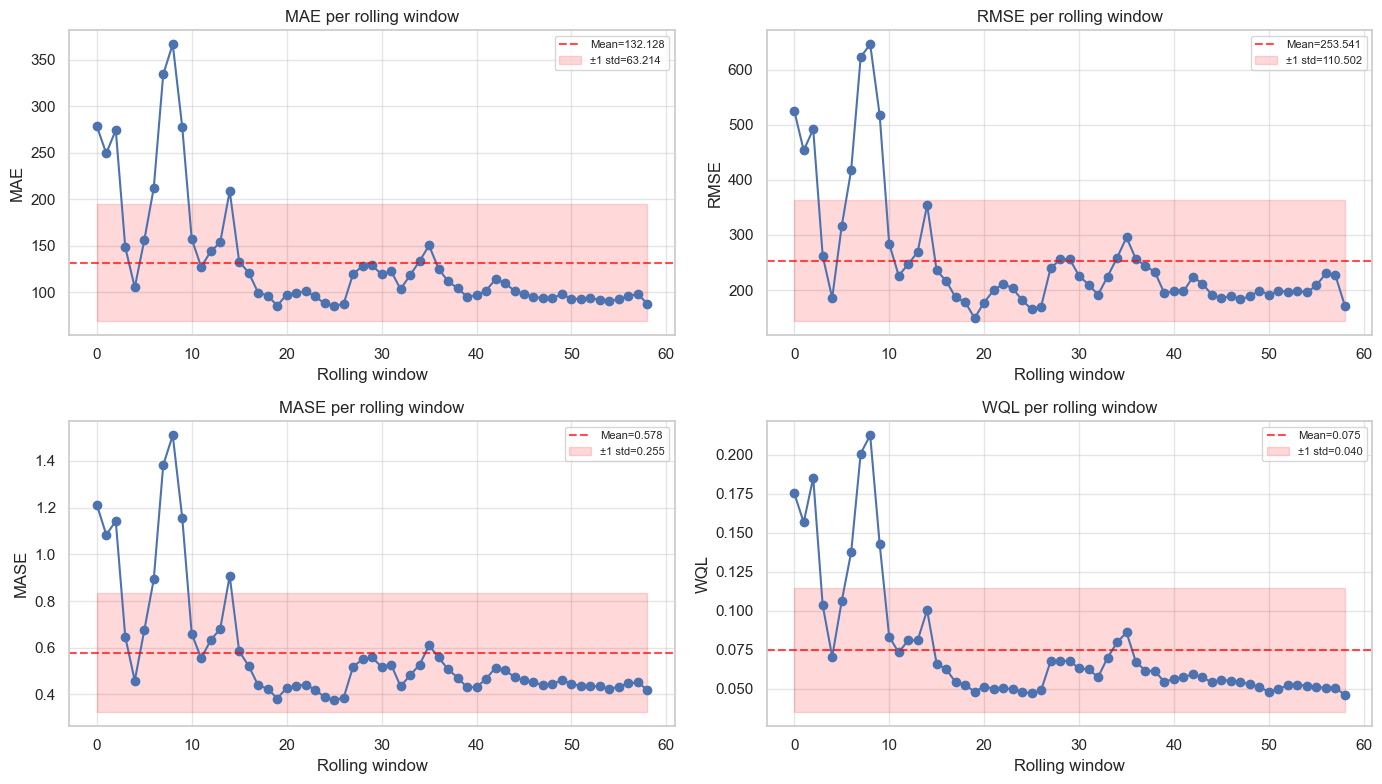

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, metric in zip(axes.flat, metric_cols):
    ax.plot(window_metrics_df['window'], window_metrics_df[metric], marker='o', linewidth=1.5)
    mean_val = window_metrics_df[metric].mean()
    std_val = window_metrics_df[metric].std()
    ax.axhline(mean_val, color='red', linestyle='--', alpha=0.7,
               label=f'Mean={mean_val:.3f}')
    ax.fill_between(window_metrics_df['window'],
                     mean_val - std_val, mean_val + std_val,
                     alpha=0.15, color='red', label=f'±1 std={std_val:.3f}')
    ax.set_xlabel('Rolling window')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} per rolling window')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 7.2 Forecast vs actual — sensores representativos (última ventana)

Se seleccionan sensores de tráfico alto, medio y bajo para inspección visual, usando la última ventana rolling.

Active sensors (median > 0): 308
  Sensor 10201: recent median = 348 veh/h
  Sensor 6805: recent median = 1261 veh/h
  Sensor 6649: recent median = 3068 veh/h


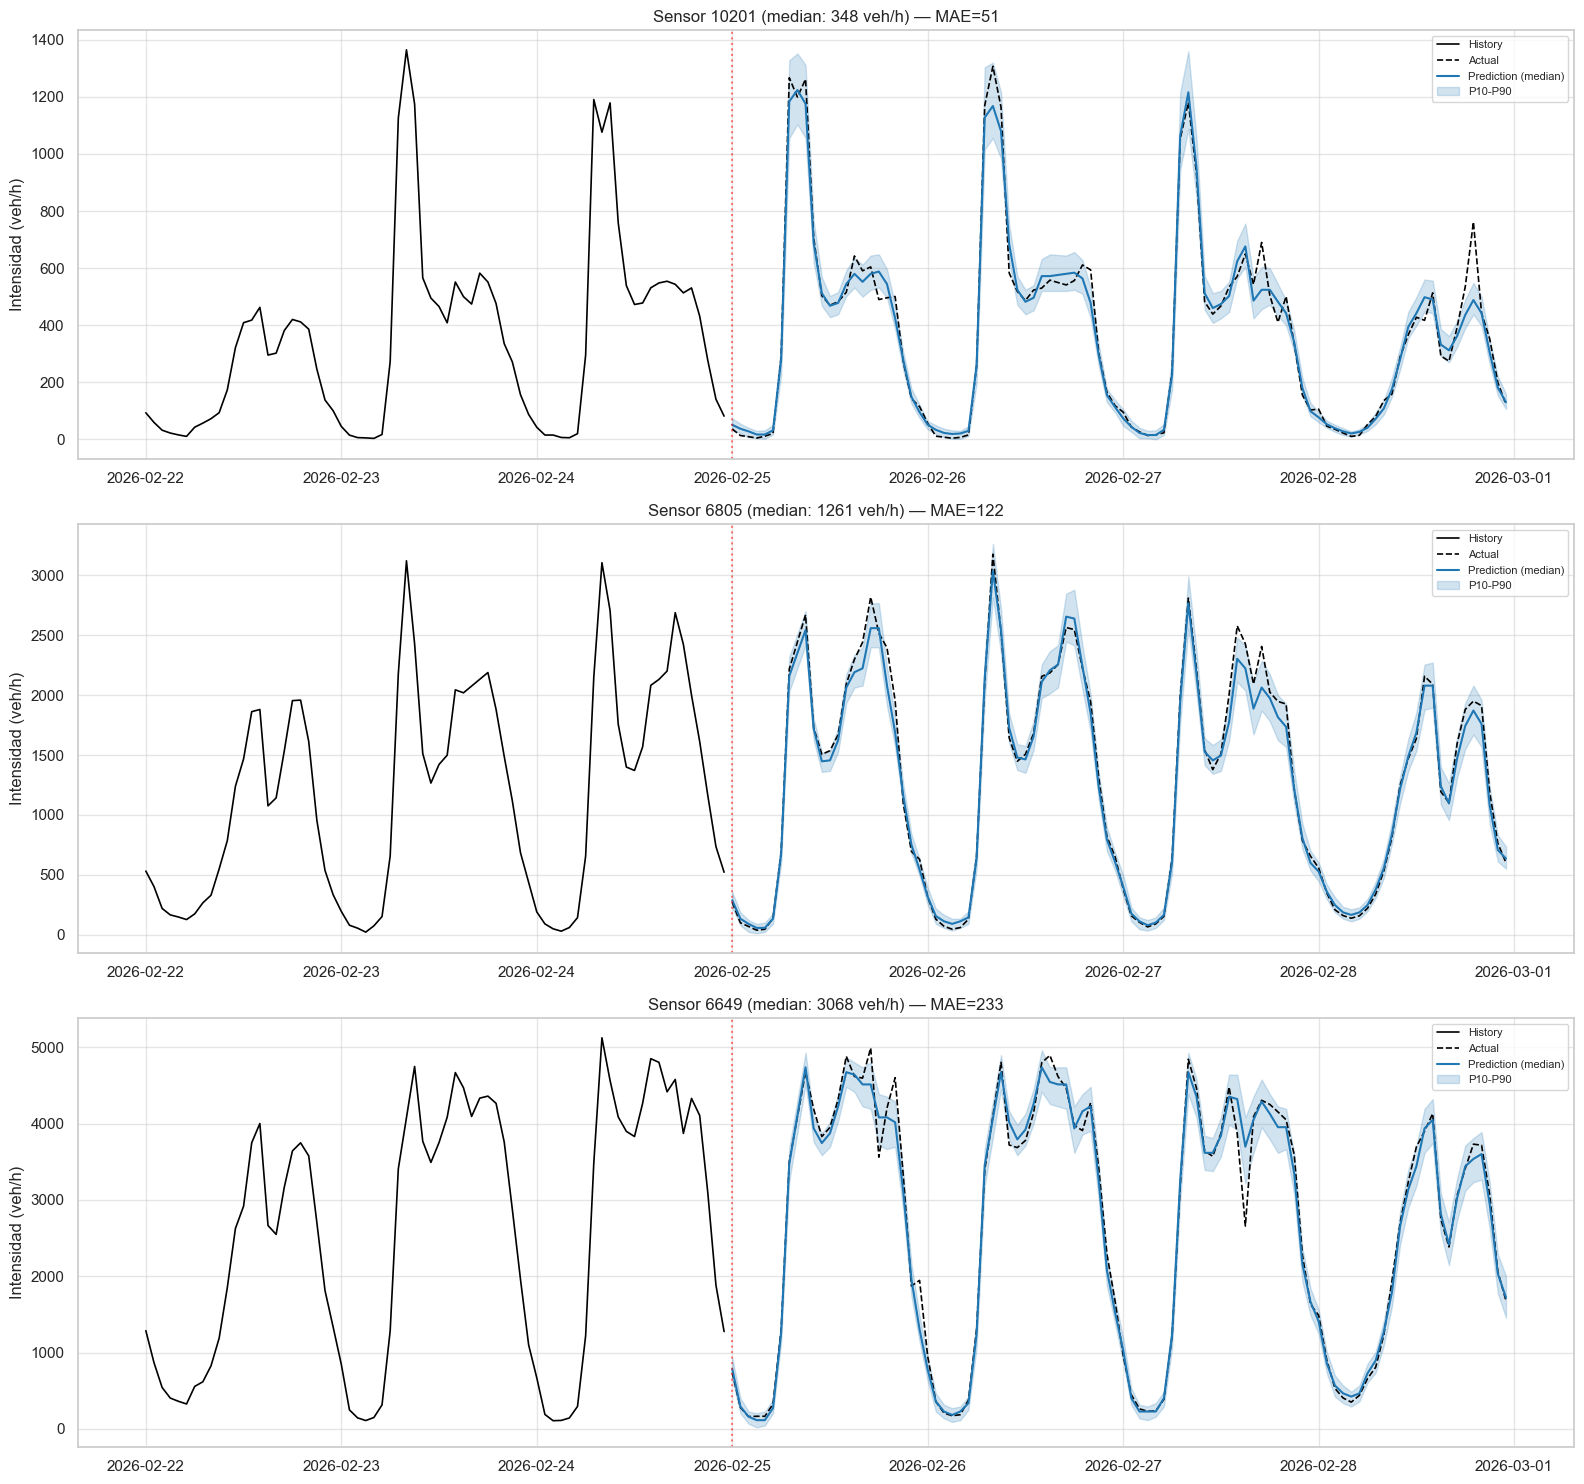

In [10]:
# Build last window's history for visualization
last_w = n_windows - 1
last_hist_parts = []

for sid, sg in sensor_groups.items():
    grp = sg['df']
    ts_idx = sg['test_start']
    pred_start = ts_idx + last_w * ROLLING_STEP
    hist_start = pred_start - HISTORY_HOURS
    last_hist_parts.append(grp.iloc[hist_start:pred_start])

last_window_history = pd.concat(last_hist_parts, ignore_index=True)
last_window_eval = all_eval_valid[all_eval_valid['window'] == last_w]

# Select representative sensors using recent history median
recent_cutoff = last_window_history[TS_COL].max() - pd.Timedelta(days=30)

recent_real = last_window_history[
    last_window_history[TS_COL] >= recent_cutoff
    ].copy()

recent_real = recent_real[recent_real['peso_loss'] > 0]
sensor_medians = recent_real.groupby(ID_COL)[TARGET].median().sort_values()
sensor_medians = sensor_medians[sensor_medians > 0]
n_active = len(sensor_medians)

sample_sensors = [
    sensor_medians.index[n_active // 10],
    sensor_medians.index[n_active // 2],
    sensor_medians.index[9 * n_active // 10],
]

print(f'Active sensors (median > 0): {n_active}')
for s in sample_sensors:
    print(f'  Sensor {s}: recent median = {sensor_medians[s]:.0f} veh/h')

CONTEXT_HOURS = 72

fig, axes = plt.subplots(len(sample_sensors), 1, figsize=(16, 5 * len(sample_sensors)), sharex=False)

for ax, sensor_id in zip(axes, sample_sensors):
    hist = last_window_history[last_window_history[ID_COL] == sensor_id].tail(CONTEXT_HOURS)
    actual = last_window_eval[last_window_eval[ID_COL] == sensor_id].sort_values(TS_COL)

    ax.plot(hist[TS_COL], hist[TARGET], color='black', linewidth=1.2, label='History')
    ax.plot(actual[TS_COL], actual[TARGET], color='black', linewidth=1.2, linestyle='--', label='Actual')
    ax.plot(actual[TS_COL], actual['predictions'], color='#1f77b4', linewidth=1.5, label='Prediction (median)')
    if '0.1' in actual.columns:
        ax.fill_between(actual[TS_COL], actual['0.1'], actual['0.9'], alpha=0.2, color='#1f77b4', label='P10-P90')

    sensor_mae = sensor_metrics[sensor_metrics[ID_COL] == sensor_id]['MAE'].values
    mae_str = f'MAE={sensor_mae[0]:.0f}' if len(sensor_mae) > 0 else ''
    ax.set_title(f'Sensor {sensor_id} (median: {sensor_medians[sensor_id]:.0f} veh/h) — {mae_str}')
    ax.set_ylabel('Intensidad (veh/h)')
    ax.legend(loc='upper right', fontsize=8)
    ax.axvline(actual[TS_COL].min(), color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 7.3 Distribución de errores por sensor y error temporal

Se muestran las distribuciones de MAE y MASE por sensor (agregadas sobre todas las ventanas rolling), y el error por hora del día y día de la semana.

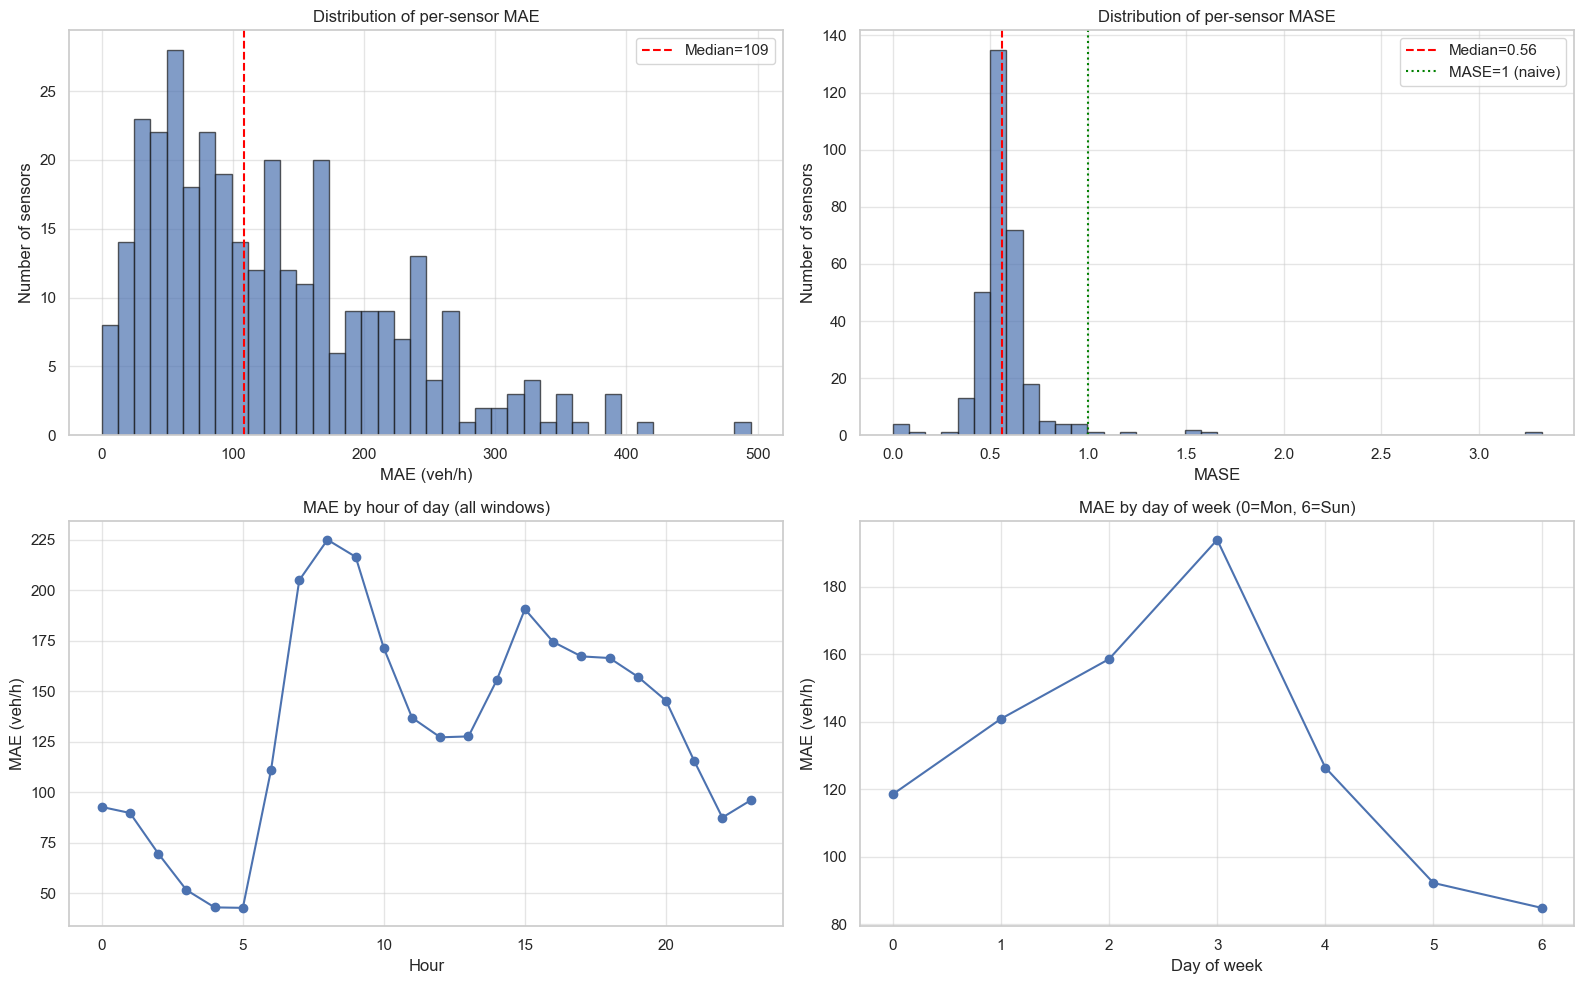

Sensors with MASE < 1 (beats naive): 98.1%


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# MAE distribution across sensors
axes[0, 0].hist(sensor_metrics['MAE'], bins=40, edgecolor='k', alpha=0.7)
axes[0, 0].axvline(sensor_metrics['MAE'].median(), color='red', linestyle='--',
                    label=f'Median={sensor_metrics["MAE"].median():.0f}')
axes[0, 0].set_xlabel('MAE (veh/h)')
axes[0, 0].set_ylabel('Number of sensors')
axes[0, 0].set_title('Distribution of per-sensor MAE')
axes[0, 0].legend()

# MASE distribution across sensors
valid_mase = sensor_metrics['MASE'].dropna()
axes[0, 1].hist(valid_mase, bins=40, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(valid_mase.median(), color='red', linestyle='--',
                    label=f'Median={valid_mase.median():.2f}')
axes[0, 1].axvline(1.0, color='green', linestyle=':', label='MASE=1 (naive)')
axes[0, 1].set_xlabel('MASE')
axes[0, 1].set_ylabel('Number of sensors')
axes[0, 1].set_title('Distribution of per-sensor MASE')
axes[0, 1].legend()

# MAE by hour of day (aggregated over all windows)
all_eval_valid_tmp = all_eval_valid.copy()
all_eval_valid_tmp['hora_dia'] = all_eval_valid_tmp[TS_COL].dt.hour
all_eval_valid_tmp['dia_semana'] = all_eval_valid_tmp[TS_COL].dt.dayofweek
all_eval_valid_tmp['abs_error'] = np.abs(all_eval_valid_tmp[TARGET] - all_eval_valid_tmp['predictions'])

all_eval_valid_tmp.groupby('hora_dia')['abs_error'].mean().plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title('MAE by hour of day (all windows)')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('MAE (veh/h)')

# MAE by day of week
all_eval_valid_tmp.groupby('dia_semana')['abs_error'].mean().plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title('MAE by day of week (0=Mon, 6=Sun)')
axes[1, 1].set_xlabel('Day of week')
axes[1, 1].set_ylabel('MAE (veh/h)')

plt.tight_layout()
plt.show()

pct_beats_naive = (valid_mase < 1.0).mean() * 100
print(f'Sensors with MASE < 1 (beats naive): {pct_beats_naive:.1f}%')

### 7.4 Error por horizonte de predicción

Además de las métricas globales agregadas sobre todas las ventanas rolling, resulta útil estudiar cómo cambia el error en función del **horizonte de predicción** dentro de cada forecast de 96 horas. Para ello, se calcula el **MAE** y el **MASE** para cada paso horario \(h = 1, \dots, 96\), agregando todas las observaciones válidas de todas las ventanas y sensores.

Este análisis permite responder a dos preguntas importantes:

1. **Si el error crece con la distancia temporal al forecast**, es decir, si predecir 4 días por delante es sistemáticamente más difícil que predecir las primeras horas.
2. **Si existen patrones intradiarios repetitivos** dentro del horizonte (por ejemplo, horas punta o valles nocturnos) que afecten más al modelo que la propia distancia al origen del forecast.

En particular, el MASE permite interpretar cada horizonte respecto al baseline naive estacional de 24 horas \((y_{t-24})\), de modo que valores inferiores a 1 indican que Chronos-2 sigue superando al baseline en ese paso horario concreto.

In [12]:
# ============================================================
# Horizon-wise MAE / MASE for Chronos-2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy evaluation rows
horizon_eval = all_eval_valid.copy()

# Map each rolling window to its forecast start timestamp
window_start_map = window_metrics_df.set_index("window")["window_start"]

# Add forecast start timestamp for each row
horizon_eval["window_start"] = horizon_eval["window"].map(window_start_map)
horizon_eval["window_start"] = pd.to_datetime(horizon_eval["window_start"])

# Horizon step within each rolling window: 1..PREDICTION_LENGTH
horizon_eval["horizon"] = (
                                  (horizon_eval[TS_COL] - horizon_eval["window_start"]).dt.total_seconds() // 3600
                          ).astype(int) + 1

# Keep only valid forecast horizons
horizon_eval = horizon_eval[
    horizon_eval["horizon"].between(1, PREDICTION_LENGTH)
].copy()

# Absolute error
horizon_eval["abs_error"] = np.abs(horizon_eval[TARGET] - horizon_eval["predictions"])

# Per-row scaled error for MASE
horizon_eval["mase_denom"] = horizon_eval[ID_COL].map(mase_denominators)
valid_mase = horizon_eval["mase_denom"].notna() & (horizon_eval["mase_denom"] > 0)

horizon_eval["scaled_abs_error"] = np.nan
horizon_eval.loc[valid_mase, "scaled_abs_error"] = (
        horizon_eval.loc[valid_mase, "abs_error"] / horizon_eval.loc[valid_mase, "mase_denom"]
)

# Aggregate by horizon across all windows and sensors
horizon_metrics = horizon_eval.groupby("horizon").agg(
    MAE=("abs_error", "mean"),
    MASE=("scaled_abs_error", "mean"),
    n_rows=("abs_error", "size"),
    n_valid_mase=("scaled_abs_error", lambda s: s.notna().sum()),
).reset_index()

print("=== Horizon-wise metrics (aggregated across all rolling windows) ===")
display(horizon_metrics.round(4))

=== Horizon-wise metrics (aggregated across all rolling windows) ===


,horizon,MAE,MASE,n_rows,n_valid_mase
0,1,70.7796,0.3185,18692,18224
1,2,60.1790,0.2731,18707,18239
2,3,47.5493,0.2170,18716,18248
3,4,34.7877,0.1582,18730,18262
4,5,30.9018,0.1418,18716,18248
...,...,...,...,...,...
91,92,161.5232,0.7234,18668,18182
92,93,146.0428,0.6451,18747,18261
93,94,116.7071,0.5068,18798,18312
94,95,85.7310,0.3743,18518,18032


La siguiente figura muestra el **MAE** y el **MASE** medios por paso horario de horizonte, agregados sobre todas las ventanas rolling y sensores válidos.

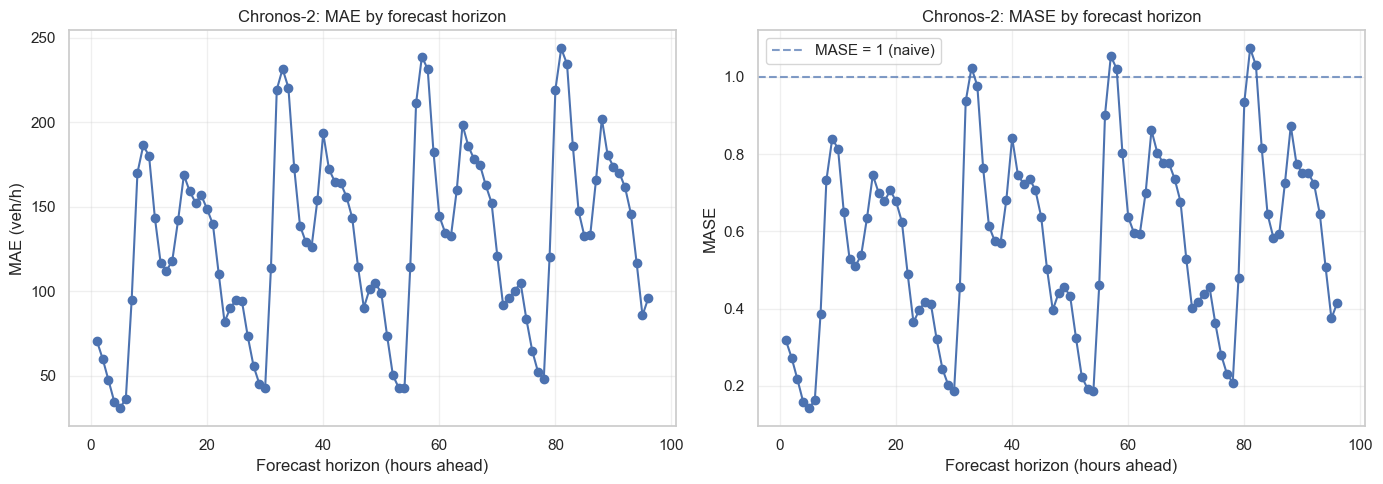

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE by horizon
axes[0].plot(horizon_metrics["horizon"], horizon_metrics["MAE"], marker="o")
axes[0].set_title("Chronos-2: MAE by forecast horizon")
axes[0].set_xlabel("Forecast horizon (hours ahead)")
axes[0].set_ylabel("MAE (veh/h)")
axes[0].grid(True, alpha=0.3)

# MASE by horizon
axes[1].plot(horizon_metrics["horizon"], horizon_metrics["MASE"], marker="o")
axes[1].axhline(1.0, linestyle="--", alpha=0.7, label="MASE = 1 (naive)")
axes[1].set_title("Chronos-2: MASE by forecast horizon")
axes[1].set_xlabel("Forecast horizon (hours ahead)")
axes[1].set_ylabel("MASE")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.5 Variabilidad temporal del error por horizonte

La curva media por horizonte resume el comportamiento típico del modelo, pero no informa sobre su **estabilidad entre ventanas rolling**. Para evaluar esta robustez, se calcula primero el MAE y el MASE para cada combinación **(ventana, horizonte)** y, a continuación, se resume cada horizonte mediante su **media** y **desviación estándar** a lo largo de las 59 ventanas.

Este análisis permite distinguir entre dos situaciones:

- horizontes con error medio alto pero estable;
- horizontes con error medio razonable pero **gran variabilidad**, lo que sugiere sensibilidad a periodos concretos del calendario (por ejemplo, festivos o transiciones anómalas).

Por tanto, estas gráficas complementan la media global y ayudan a identificar si los peores resultados se deben a una degradación estructural del horizonte largo o, por el contrario, a unas pocas ventanas especialmente difíciles.

In [14]:
# ============================================================
# Per-window, per-horizon metrics
# ============================================================

horizon_window_metrics = (
    horizon_eval.groupby(["window", "horizon"])
    .apply(
        lambda g: pd.Series({
            "MAE": g["abs_error"].mean(),
            "MASE": g["scaled_abs_error"].mean(),
            "n_rows": len(g),
        }),
        include_groups=False
    )
    .reset_index()
)

# Summary across windows for each horizon
horizon_summary = horizon_window_metrics.groupby("horizon").agg(
    MAE_mean=("MAE", "mean"),
    MAE_std=("MAE", "std"),
    MASE_mean=("MASE", "mean"),
    MASE_std=("MASE", "std"),
).reset_index()

display(horizon_summary.round(4))

,horizon,MAE_mean,MAE_std,MASE_mean,MASE_std
0,1,73.2094,73.8236,0.3260,0.2552
1,2,60.4390,73.9156,0.2726,0.3191
2,3,47.7807,78.3749,0.2165,0.3402
3,4,34.9659,41.1823,0.1580,0.1726
4,5,30.9689,19.8449,0.1417,0.0845
...,...,...,...,...,...
91,92,162.1011,64.6349,0.7232,0.2621
92,93,146.3070,47.6598,0.6451,0.1872
93,94,117.1790,52.1051,0.5072,0.2054
94,95,85.5228,37.3714,0.3718,0.1442


La siguiente figura muestra la **media ± 1 desviación estándar** del MAE y el MASE para cada horizonte horario, calculada sobre las 59 ventanas rolling.

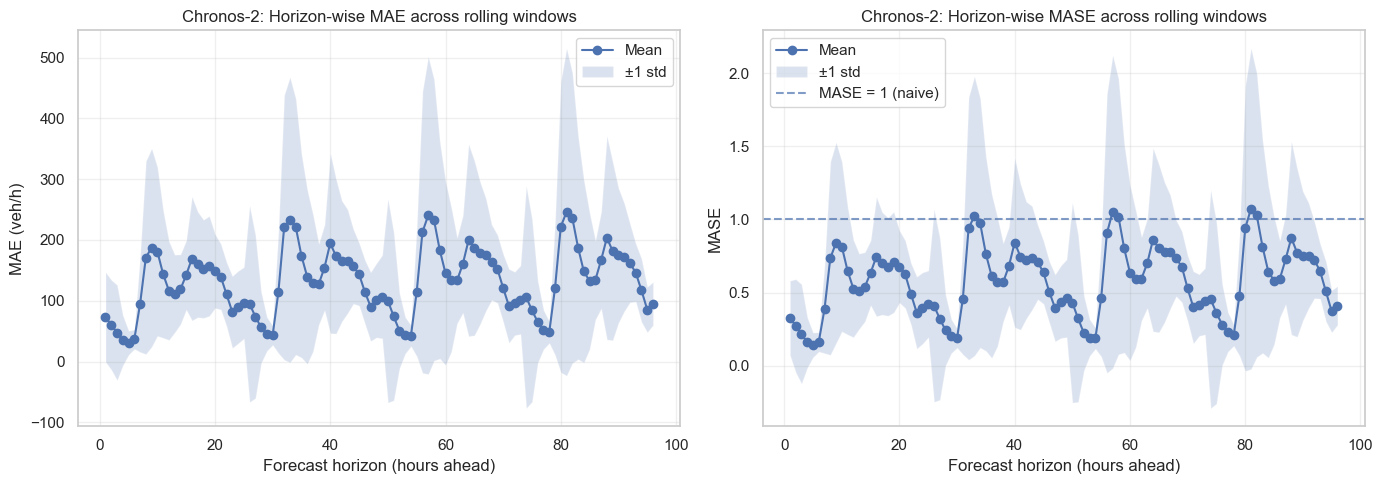

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE with ±1 std band
axes[0].plot(horizon_summary["horizon"], horizon_summary["MAE_mean"], marker="o", label="Mean")
axes[0].fill_between(
    horizon_summary["horizon"],
    horizon_summary["MAE_mean"] - horizon_summary["MAE_std"],
    horizon_summary["MAE_mean"] + horizon_summary["MAE_std"],
    alpha=0.2,
    label="±1 std"
)
axes[0].set_title("Chronos-2: Horizon-wise MAE across rolling windows")
axes[0].set_xlabel("Forecast horizon (hours ahead)")
axes[0].set_ylabel("MAE (veh/h)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MASE with ±1 std band
axes[1].plot(horizon_summary["horizon"], horizon_summary["MASE_mean"], marker="o", label="Mean")
axes[1].fill_between(
    horizon_summary["horizon"],
    horizon_summary["MASE_mean"] - horizon_summary["MASE_std"],
    horizon_summary["MASE_mean"] + horizon_summary["MASE_std"],
    alpha=0.2,
    label="±1 std"
)
axes[1].axhline(1.0, linestyle="--", alpha=0.7, label="MASE = 1 (naive)")
axes[1].set_title("Chronos-2: Horizon-wise MASE across rolling windows")
axes[1].set_xlabel("Forecast horizon (hours ahead)")
axes[1].set_ylabel("MASE")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.6 Rendimiento agregado por bloques de horizonte

Para facilitar la interpretación del forecast de 96 horas, se agrupan los pasos horarios en cuatro bloques de 24 horas:

- **1–24h**
- **25–48h**
- **49–72h**
- **73–96h**

Esta agregación permite resumir el comportamiento del modelo por **día de anticipación**, reduciendo el ruido de las curvas paso a paso. Así, puede evaluarse de forma más clara si el modelo presenta una degradación progresiva al avanzar desde el primer hasta el cuarto día, o si el rendimiento se mantiene relativamente estable y las diferencias observadas se deben principalmente a patrones intradiarios específicos.

Este resumen es especialmente útil para la discusión final del caso Chronos-2, ya que traduce el análisis por horizonte a una escala más interpretable para forecasting operativo multidiario.

In [16]:
horizon_eval["horizon_block"] = pd.cut(
    horizon_eval["horizon"],
    bins=[0, 24, 48, 72, 96],
    labels=["1-24h", "25-48h", "49-72h", "73-96h"]
)

block_metrics = horizon_eval.groupby("horizon_block").agg(
    MAE=("abs_error", "mean"),
    MASE=("scaled_abs_error", "mean"),
    n_rows=("abs_error", "size"),
).reset_index()

print("=== Metrics by horizon block ===")
display(block_metrics.round(4))

=== Metrics by horizon block ===


/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_82757/3596740222.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  block_metrics = horizon_eval.groupby("horizon_block").agg(


,horizon_block,MAE,MASE,n_rows
0,1-24h,114.5300,0.5112,446776
1,25-48h,133.7286,0.5870,446811
2,49-72h,138.3353,0.6056,446770
3,73-96h,140.2254,0.6101,446689


## 8. Conclusiones

### 8.1 Resumen del enfoque

Se ha implementado el modelo fundacional **Amazon Chronos-2** — variante **ALL_FORE** — para forecasting de la intensidad de tráfico en los **351 sensores** de la M30 de Madrid, con un horizonte de predicción de **96 horas** (4 días) y un contexto histórico de **168 horas** (7 días). El modelo se ejecutó en Apple Silicon (MPS) con `bfloat16`.

Variante **ALL_FORE**: incluye el conjunto completo de covariables futuras para alineación de equidad con TimeXer — `forecast_temp`, `forecast_prec`, `angle_sin`, `angle_cos`, `dia_semana`, `hora_dia`, `mes`, `festivo`, `vispera_festivo`, `distrito` — así como covariables históricas (`ocupacion`, `vmed`, temperatura y precipitación observadas).

### 8.2 Metodología de evaluación rolling

Se ha aplicado **evaluación rolling** con ventanas desplazadas de 24 horas sobre un test split de los últimos **2 meses** de datos (1,488 horas por sensor, del 29 dic 2025 al 28 feb 2026). Esto ha producido **59 ventanas rolling** independientes, generando un total de **1,787,046 filas válidas** de evaluación (`peso_loss > 0`). El tiempo total de inferencia fue de **1 h 22 min 41 s** (~84 s/ventana).

### 8.3 Parámetros configurables

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `PREDICTION_LENGTH` | 96 h (4 días) | Horizonte de predicción por ventana |
| `HISTORY_HOURS` | 168 h (7 días) | Contexto histórico alimentado al modelo |
| `ROLLING_STEP` | 24 h | Desplazamiento entre ventanas consecutivas |
| `TEST_MONTHS` | 2 meses | Últimos 2 meses de datos reservados para test (1,488 h, ~14.5%) |
| `VAL_LENGTH` | 672 h (28 días) | Periodo de validación previo al test |

### 8.4 Rendimiento global (media ± desviación sobre 59 ventanas rolling)

| Métrica | Media ± Std | Min | Max | Interpretación |
|---------|------------|-----|-----|----------------|
| **MAE** | 132.1 ± 63.2 veh/h | 85.7 | 366.9 | Error absoluto medio |
| **RMSE** | 253.5 ± 110.5 veh/h | 149.1 | 646.2 | Penaliza errores grandes; ratio RMSE/MAE ≈ 1.92 |
| **MASE** | 0.578 ± 0.255 | 0.377 | 1.510 | < 1 indica superioridad sobre naive forecast |
| **WQL** | 0.0747 ± 0.0400 | 0.0459 | 0.2127 | Calibración de cuantiles |

El MASE medio de **0.578** indica que Chronos-2 ALL_FORE reduce el error del forecast ingenuo en un **42.2%** en promedio, aunque con variabilidad significativa (std = 0.255).

### 8.5 Análisis temporal de la variabilidad

La evaluación rolling revela un patrón claro de **degradación durante el periodo navideño** (finales de diciembre – primera semana de enero):

- **Ventanas 0–2 y 7–9** (29 dic – 3 ene y 5 ene – 10 ene 2026): las peores métricas del estudio, con MAE alcanzando **366.9 veh/h** (ventana 8) y MASE > 1.0 en seis ventanas (máx. 1.510). Esto se corresponde con el periodo navideño y de Reyes, donde los patrones de tráfico son atípicos y el contexto histórico de solo 7 días no es representativo.
- **Ventanas 16–26** (14 ene – 27 ene 2026): estabilización, con MAE cayendo a **85.7–121.2 veh/h** y MASE estable en torno a 0.38–0.52. El modelo funciona óptimamente cuando el contexto histórico contiene semanas laborables regulares. La mejor ventana individual es la 25 (MAE=85.7 veh/h, MASE=0.377).
- **Ventanas 27–58** (25 ene – 28 feb 2026): rendimiento estable con fluctuaciones menores (MAE 87.9–150.5 veh/h, MASE 0.42–0.61), mostrando que el modelo mantiene su precisión a lo largo de semanas normales.

Este hallazgo tiene implicaciones prácticas: el rendimiento del modelo depende fuertemente de que el contexto histórico contenga patrones representativos. Periodos atípicos (festivos, eventos especiales) degradan significativamente la predicción.

### 8.6 Rendimiento por sensor (331 sensores, agregado sobre 59 ventanas)

- **MAE mediana**: 108.7 veh/h (P25=56.5, P75=183.2), con máximo de 494.6 veh/h en sensores de alto tráfico.
- **MASE mediana**: 0.557 (P25=0.514, P75=0.611). El **97.4%** de los sensores con MASE válido obtienen MASE < 1, superando al forecast ingenuo.
- **MASE media**: 0.579 — cercana a la mediana, indicando una distribución relativamente simétrica (máximo 3.319).
- **WQL mediana**: 0.073 — calibración razonable de los intervalos de predicción.

De los 351 sensores, **331** tuvieron al menos una observación válida. Los 20 restantes son sensores inactivos o sin datos válidos en el periodo de test.

### 8.7 Rendimiento por bloque de horizonte

Agregando los pasos horarios en cuatro bloques de 24 horas sobre las 59 ventanas y todos los sensores:

| Bloque | MAE (veh/h) | MASE |
|--------|-------------|------|
| 1–24h  | 114.5 | 0.511 |
| 25–48h | 133.7 | 0.587 |
| 49–72h | 138.3 | 0.606 |
| 73–96h | 140.2 | 0.610 |

El modelo muestra su mejor rendimiento en el primer día (MASE=0.511) y experimenta una degradación progresiva hasta el cuarto día (MASE=0.610, +19.4% sobre el bloque 1). El incremento es más pronunciado entre el primer y segundo bloque (+14.8%), y se modera a partir del tercer día, aunque sin estabilizarse completamente. Este patrón indica que Chronos-2 ALL_FORE **mantiene una precisión razonable a lo largo de los 4 días de horizonte**, si bien la calidad del forecast decrece de forma gradual con la distancia temporal.

### 8.8 Calidad de datos

De las ~33,696 filas por ventana (96h × 351 sensores), entre el **85–93%** correspondieron a mediciones reales (`peso_loss > 0`). Se observa una tendencia al alza en filas válidas conforme avanza el test (de ~29,500 en enero a ~31,400 en febrero), posiblemente por recuperación de sensores o menor tasa de imputación.

### 8.9 Valoración global

**Fortalezas**:
1. **Sin fine-tuning**: modelo fundacional genérico que supera al naive en el **97.4%** de los sensores con MASE válido.
2. **Evaluación robusta**: 59 ventanas rolling proporcionan estimaciones fiables de media y dispersión, revelando que la variabilidad entre ventanas (std MAE = 63.2) es sustancial y una evaluación single-shot habría sido insuficiente.
3. **Estabilidad en el horizonte largo**: aunque el MASE aumenta progresivamente desde el bloque 1–24h (0.511) hasta el bloque 73–96h (0.610), el rango de variación es moderado (~19% de incremento total), lo que indica ausencia de degradación catastrófica.
4. **Covariables completas**: integración de covariables históricas (ocupación, velocidad, temperatura, precipitación), futuras (calendario, pronóstico meteorológico, ciclo anual codificado) y espaciales (distrito) — alineación completa con TimeXer.

**Limitaciones**:
- **Sensibilidad a periodos atípicos**: el periodo navideño (ventanas 0–2 y 7–9) provoca MASE > 1.0, con máximo de 1.510. Un contexto histórico de solo 7 días es insuficiente para capturar la estacionalidad de eventos anuales.
- **Variabilidad elevada**: la std del MAE (63.2) es el 47.8% de la media (132.1), indicando que el rendimiento fluctúa considerablemente según el periodo temporal.
- **Ratio RMSE/MAE ≈ 1.92**: presencia de errores puntuales elevados, probablemente asociados a eventos atípicos no anticipables.
- **Tiempo de inferencia**: ~84 s/ventana en Apple Silicon (MPS) con `bfloat16`; con 59 ventanas el tiempo total fue **1 h 22 min**, lo que limita la viabilidad para inferencia operativa en tiempo real.